In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score, roc_curve
from sklearn.preprocessing import scale
import pandas as pd

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns



# File ID from your Google Sheets link
file_id = '1VfM7Q5cAysB4xYyg7CmXzX5CRMFZfBQx'

# Construct the download URL for the CSV format
download_url = f'https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(download_url)

# Identify date columns
date_columns = ['Customer_Since', 'Period', 'Open_Date']  # Replace with your actual date column names

# Define the date format
date_format = '%m/%d/%y'  # Month/Day/Year with two-digit year

# Convert date columns from string to datetime using the specified format
for col in date_columns:
    df[col] = pd.to_datetime(df[col], format=date_format, errors='coerce')

# Handle missing or invalid dates
df[date_columns] = df[date_columns].fillna(pd.Timestamp('1970-01-01'))


# Extract numerical features from date columns
for col in date_columns:
    df[f'{col}_year'] = df[col].dt.year
    df[f'{col}_month'] = df[col].dt.month
    df[f'{col}_day'] = df[col].dt.day
    df[f'{col}_dayofweek'] = df[col].dt.dayofweek
    df[f'{col}_dayofyear'] = df[col].dt.dayofyear
    # If you need the timestamp
    df[f'{col}_timestamp'] = df[col].astype(np.int64) // 10**9    # Convert to Unix timestamp in seconds

# Drop original date columns if they are no longer needed
df = df.drop(columns=date_columns)

#Create Dummies
# List of qualitative columns for which to create dummy variables
qualitative_columns = ['Age_demographics', 'Customer_type', 'Personal_customer_type', 'Business_type', 'Business_sub_type']

# Create a copy of the original data to avoid modifying it directly
data_with_all_dummies = df.copy()

# Generate dummy variables for each qualitative column
for col in qualitative_columns:
    dummies = pd.get_dummies(data_with_all_dummies[col], prefix=col, drop_first=True).astype(int)
    data_with_all_dummies = pd.concat([data_with_all_dummies, dummies], axis=1)

# Drop the original qualitative columns as they are now represented by dummy variables
data_with_all_dummies.drop(qualitative_columns, axis=1, inplace=True)




data_with_all_dummies.replace(["", " ", "NA", "N/A", "None"], np.nan, inplace=True)
data_with_all_dummies.dropna(inplace=True)
y = data_with_all_dummies[['Churned']]
X = data_with_all_dummies.drop('Churned',axis = 1)

total_nan = data_with_all_dummies.isnull().sum().sum()
print("Total number of NaN values in the DataFrame:", total_nan)
y = data_with_all_dummies["Churned"]
X = data_with_all_dummies.drop("Churned", axis=1)

y.info()
X.info()

# Step 2.1: Calculate VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare the data for VIF calculation
# Exclude the target variable and any non-numeric columns
numeric_cols = data_with_all_dummies.select_dtypes(include=[np.number]).columns

target_variable = 'Churned'  # Replace with your actual target variable name
X = data_with_all_dummies[numeric_cols].drop(columns=[target_variable])

# VIF DataFrame
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
X = X.dropna()
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


# Set display option to show all rows
pd.set_option('display.max_rows', None)

# Now when you print the DataFrame, it will display all rows
print("\nVariance Inflation Factors (VIF):")
print(vif_data)

# Assuming 'vif_data' is your DataFrame containing VIF values
# Set display option to show all rows
pd.set_option('display.max_rows', None)

# Print the full VIF DataFrame
print("\nVariance Inflation Factors (VIF):")
print(vif_data)

# Handle potential NaN or infinite VIF values
vif_data_clean = vif_data.copy()
vif_data_clean = vif_data_clean.replace([np.inf, -np.inf], np.nan)
vif_data_clean = vif_data_clean.dropna(subset=['VIF'])

# Variables with VIF less than 1
vif_less_than_1 = vif_data_clean[vif_data_clean['VIF'] < 1]
count_less_than_1 = vif_less_than_1.shape[0]

# Variables with VIF between 1 and 5 (inclusive)
vif_between_1_and_5 = vif_data_clean[(vif_data_clean['VIF'] >= 1) & (vif_data_clean['VIF'] <= 5)]
count_between_1_and_5 = vif_between_1_and_5.shape[0]

# Variables with VIF greater than 5
vif_greater_than_5 = vif_data_clean[vif_data_clean['VIF'] > 5]
count_greater_than_5 = vif_greater_than_5.shape[0]

# Print variables with VIF less than 1
print("\nVariables with VIF less than 1:")
print(vif_less_than_1)
print("Count of variables with VIF less than 1:", count_less_than_1)

# Print variables with VIF between 1 and 5
print("\nVariables with VIF between 1 and 5:")
print(vif_between_1_and_5)
print("Count of variables with VIF between 1 and 5:", count_between_1_and_5)

# Print variables with VIF greater than 5
print("\nVariables with VIF greater than 5:")
print(vif_greater_than_5)
print("Count of variables with VIF greater than 5:", count_greater_than_5)

# Reset Pandas display options if needed
pd.reset_option('display.max_rows')

Total number of NaN values in the DataFrame: 0
<class 'pandas.core.series.Series'>
Index: 36209 entries, 1 to 46063
Series name: Churned
Non-Null Count  Dtype
--------------  -----
36209 non-null  int64
dtypes: int64(1)
memory usage: 565.8 KB
<class 'pandas.core.frame.DataFrame'>
Index: 36209 entries, 1 to 46063
Columns: 138 entries, Age to Business_sub_type_Trust
dtypes: float64(39), int32(15), int64(84)
memory usage: 36.3 MB


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [7]:
from sklearn.preprocessing import StandardScaler

#Drop Response Variable
y = data_with_all_dummies["Churned"]

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = 10**np.linspace(10, -2, 100) * 0.5

lasso = Lasso()
coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

np.shape(coefs)
"""
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')
"""
# Split data into training and test sets
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Define your alpha range
alphas = 10**np.linspace(10, -2, 100) * 0.5

# Manually normalize the training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LassoCV with cross-validation (10-fold)
lassocv = LassoCV(alphas=alphas, cv=10, max_iter=100000)
lassocv.fit(X_train_scaled, y_train)

# Display the best alpha (lambda)
print("Best alpha (lambda):", lassocv.alpha_)

# Using the best lambda (alpha) from LassoCV to fit the final Lasso model
lasso4 = Lasso(alpha=lassocv.alpha_)
lasso4.fit(X_train_scaled, y_train)

# Calculate the mean squared error on the test set
mse = mean_squared_error(y_test, lasso4.predict(X_test_scaled))
print("Mean Squared Error:", mse)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd

# Assuming X_train, y_train, X_test, y_test are your training and testing sets
scaler = StandardScaler()

# Manually scale the training and test data
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform training data
X_test_scaled = scaler.transform(X_test)  # Transform test data using the same scaler

# Initialize the Lasso model without the 'normalize' argument
lasso2 = Lasso(alpha=0.005)
lasso2.fit(X_train_scaled, y_train)  # Fit the Lasso model on the scaled training data

# Predict using the scaled test data
pred2 = lasso2.predict(X_test_scaled)

# Print coefficients
print(pd.Series(lasso2.coef_, index=X_train.columns))

# Calculate and print the mean squared error
print("Mean Squared Error:", mean_squared_error(y_test, pred2))

# Get the Lasso coefficients
lasso_coef = pd.Series(lasso2.coef_, index=X_train.columns)

# Filter out coefficients that are zero
non_zero_coef = lasso_coef[lasso_coef != 0]

# Print the non-zero coefficients (features selected by Lasso)
print(non_zero_coef)

non_zero_coef.info()


# Add constant for statsmodels
columns = ["Overdraft_limit", "Overdrafts_Charged_QTD", "Overdrafts_Waived_QTD",
           'Status_Code_L', 'Credit_#_of_Transactions', 'Debit_#_of_Transactions',
           'ACH_Deposits_Count', 'Age_demographics_Millennial']

# Select the columns from the DataFrame X
x = X[columns]
x = sm.add_constant(x)

# Fit the logistic regression model
model = sm.Logit(y, x).fit()

# Print the summary
print(model.summary())



Best alpha (lambda): 0.005
Mean Squared Error: 0.021430221190253635
Age                                -0.0
Region                              0.0
Branch_number                       0.0
Balance                            -0.0
CK_SV_average_12_month_balance     -0.0
                                   ... 
Business_sub_type_Member LLC        0.0
Business_sub_type_Non-Profit        0.0
Business_sub_type_Not Applicable    0.0
Business_sub_type_Partnership       0.0
Business_sub_type_Trust             0.0
Length: 138, dtype: float64
Mean Squared Error: 0.021430221190253635
Overdraft_limit               -0.002306
Overdrafts_Charged_QTD         0.001119
Overdrafts_Waived_QTD          0.001951
Status_Code_L                  0.011250
Credit_#_of_Transactions      -0.000207
Debit_#_of_Transactions       -0.002298
ACH_Deposits_Count            -0.000914
Age_demographics_Millennial    0.000667
dtype: float64
<class 'pandas.core.series.Series'>
Index: 8 entries, Overdraft_limit to Age_demographic

count    36209.000000
mean         0.707145
std          0.455079
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64
[[10542 24889]
 [   62   716]]
accuracy = 31.091717528791186%
Recall = 92.03%
Precision = 2.80%
F1-Score = 5.43%
Specificity = 29.75%
False Positive Rate (FPR) = 70.25%
Logistic: ROC AUC=0.609


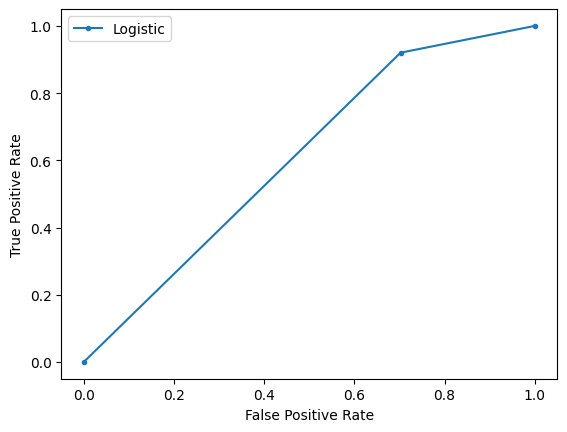

In [8]:
from sklearn.metrics import confusion_matrix



predicted_probabilities = model.predict(x)
predicted_probabilities

#The following command transforms all the elements with predicted probabilities of default greater than 0.5 to Yes=1
predicted_probabilities_2 = predicted_probabilities.apply(lambda x: 1 if x > 0.01 else 0)
predicted_probabilities_2.head()


print(predicted_probabilities_2.describe())
type(predicted_probabilities_2)


predicted_probabilities_array = predicted_probabilities_2.values.reshape(-1,1)  # change to array

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y, predicted_probabilities_2).ravel()

# Use  confusion matrix to measure the accuracy of our model.

print(confusion_matrix(y, predicted_probabilities_2))


accuracy = np.mean(predicted_probabilities_2 == y)
print ('accuracy = {0}%'.format(accuracy*100))

from sklearn.metrics import recall_score
# Recall
recall = recall_score(y, predicted_probabilities_2)
print('Recall = {:.2f}%'.format(recall * 100))

from sklearn.metrics import precision_score
# Precision
precision = precision_score(y, predicted_probabilities_2)
print('Precision = {:.2f}%'.format(precision * 100))

from sklearn.metrics import f1_score
# F1-Score
f1 = f1_score(y, predicted_probabilities_2, average='binary')
print('F1-Score = {:.2f}%'.format(f1 * 100))



# Specificity
specificity = tn / (tn + fp)
print('Specificity = {:.2f}%'.format(specificity * 100))

# False Positive Rate (FPR)
fpr_value = fp / (fp + tn)
print('False Positive Rate (FPR) = {:.2f}%'.format(fpr_value * 100))


from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
# calculate scores

lr_auc = roc_auc_score(y, predicted_probabilities_2)
# summarize scores

print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves


lr_fpr, lr_tpr, thresholds = roc_curve(y,  predicted_probabilities_2)
# plot the roc curve for the model

pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

In [9]:
# Extract model parameters, p-values, and confidence intervals into a DataFrame
summary_df = pd.DataFrame({
    'Coefficients': model.params,
    'P-values': model.pvalues,
    'Confidence Interval Lower': model.conf_int()[0],
    'Confidence Interval Upper': model.conf_int()[1]
})

# Save the summary DataFrame to an Excel file
excel_file = "model_summary.xlsx"
summary_df.to_excel(excel_file, index=True)
from google.colab import files
# Download the Excel file
#files.download(excel_file)

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score, roc_curve
from sklearn.preprocessing import scale
import pandas as pd

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns



# File ID from your Google Sheets link
file_id = '12kJ9G5KtXFI3o4Y-lSrkK2U1jZMCRwB7'

# Construct the download URL for the CSV format
download_url = f'https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(download_url)

# Identify date columns
date_columns = ['Customer_Since', 'Period', 'Open_Date']  # Replace with your actual date column names

# Define the date format
date_format = '%m/%d/%y'  # Month/Day/Year with two-digit year

# Convert date columns from string to datetime using the specified format
for col in date_columns:
    df[col] = pd.to_datetime(df[col], format=date_format, errors='coerce')

# Handle missing or invalid dates
df[date_columns] = df[date_columns].fillna(pd.Timestamp('1970-01-01'))


# Extract numerical features from date columns
for col in date_columns:
    df[f'{col}_year'] = df[col].dt.year
    df[f'{col}_month'] = df[col].dt.month
    df[f'{col}_day'] = df[col].dt.day
    df[f'{col}_dayofweek'] = df[col].dt.dayofweek
    df[f'{col}_dayofyear'] = df[col].dt.dayofyear
    # If you need the timestamp
    df[f'{col}_timestamp'] = df[col].astype(np.int64) // 10**9    # Convert to Unix timestamp in seconds

# Drop original date columns if they are no longer needed
df = df.drop(columns=date_columns)

#Create Dummies
# List of qualitative columns for which to create dummy variables
qualitative_columns = ['Age_demographics', 'Customer_type', 'Personal_customer_type', 'Business_type', 'Business_sub_type']

# Create a copy of the original data to avoid modifying it directly
data_with_all_dummies = df.copy()

# Generate dummy variables for each qualitative column
for col in qualitative_columns:
    dummies = pd.get_dummies(data_with_all_dummies[col], prefix=col, drop_first=True).astype(int)
    data_with_all_dummies = pd.concat([data_with_all_dummies, dummies], axis=1)

# Drop the original qualitative columns as they are now represented by dummy variables
data_with_all_dummies.drop(qualitative_columns, axis=1, inplace=True)



In [ ]:
data_with_all_dummies